In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully')

All libraries loaded successfully


In [14]:
DATA_DIR = '../../ravdess'

# quick check
for root, dirs, files in os.walk(DATA_DIR):
    wav_files = [f for f in files if f.endswith('.wav')]
    if wav_files:
        print(root, '->', len(wav_files), 'files')
        break

../../ravdess\Actor_01 -> 60 files


In [15]:
EMOTION_MAP = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

def extract_features(file_path):
    """Load an audio file and return its mean MFCC feature vector."""
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfccs.T, axis=0)

def get_emotion_label(filename):
    code = filename.split('-')[2]
    return EMOTION_MAP[code]

print('Functions ready')

Functions ready


In [16]:
features_list = []
labels_list = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith('.wav'):
            path = os.path.join(root, file)
            try:
                feat = extract_features(path)
                label = get_emotion_label(file)
                features_list.append(feat)
                labels_list.append(label)
            except Exception as e:
                print('Skipped', file, '-', e)

print('Total samples loaded:', len(features_list))
print('Emotion classes found:', set(labels_list))

Total samples loaded: 2880
Emotion classes found: {'calm', 'fearful', 'happy', 'angry', 'sad', 'disgust', 'neutral', 'surprised'}


In [17]:
X = np.array(features_list)

le = LabelEncoder()
y = le.fit_transform(labels_list)

print('Feature matrix shape:', X.shape)
print('Classes:', list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Feature matrix shape: (2880, 40)
Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Train shape: (2304, 40)  Test shape: (576, 40)


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
print('Random Forest accuracy:', accuracy_score(y_test, rf_preds))

Random Forest accuracy: 0.9270833333333334


In [19]:
num_classes = len(le.classes_)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │          10,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,168 (203.78 KB)

 Trainable params: 52,168 (203.78 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2899 - loss: 1.8690 - val_accuracy: 0.3958 - val_loss: 1.6212
Epoch 2/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4275 - loss: 1.5193 - val_accuracy: 0.4809 - val_loss: 1.3551
Epoch 3/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5048 - loss: 1.3257 - val_accuracy: 0.5556 - val_loss: 1.2104
Epoch 4/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5603 - loss: 1.1918 - val_accuracy: 0.6146 - val_loss: 1.0468
Epoch 5/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6220 - loss: 1.0447 - val_accuracy: 0.6406 - val_loss: 0.9485
Epoch 6/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6315 - loss: 0.9723 - val_accuracy: 0.6215 - val_loss: 0.9385
Epoch 7/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6788 - loss: 0.8731 - val_accuracy: 0.7188 - val_loss: 0.8251
Epoch 8/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6992 - loss: 0.8272 - val_accuracy: 0.

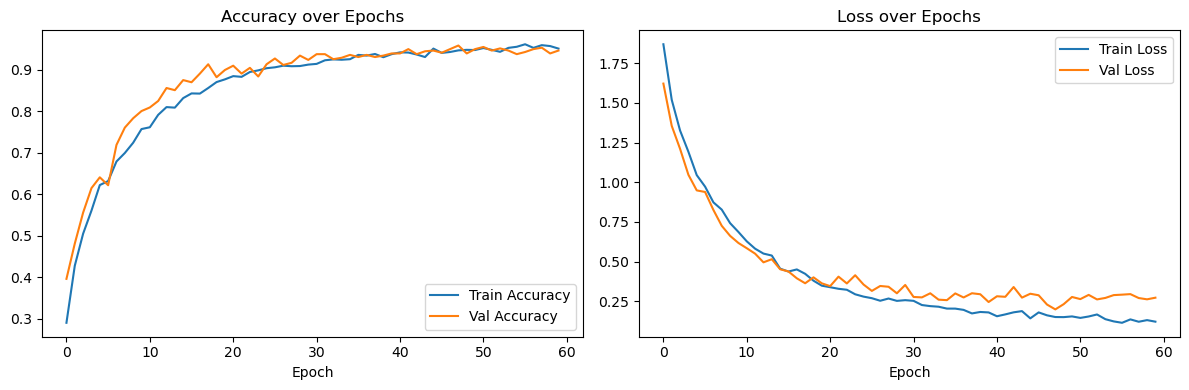

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/training_curves.png', dpi=150)
plt.show()

In [22]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f'Final Test Accuracy: {test_accuracy:.4f}\n')

report = classification_report(y_test, y_pred, target_names=le.classes_)
print(report)

with open('outputs/classification_report.txt', 'w') as f:
    f.write(f'Final Test Accuracy: {test_accuracy:.4f}\n\n')
    f.write(report)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Final Test Accuracy: 0.9462

              precision    recall  f1-score   support

       angry       0.97      1.00      0.99        76
        calm       0.99      0.95      0.97        77
     disgust       0.97      0.90      0.93        77
     fearful       0.93      0.97      0.95        77
       happy       0.97      0.95      0.96        77
     neutral       0.90      1.00      0.95        38
         sad       0.90      0.91      0.90        77
   surprised       0.92      0.92      0.92        77

    accuracy                           0.95       576
   macro avg       0.94      0.95      0.95       576
weighted avg       0.95      0.95      0.95       576



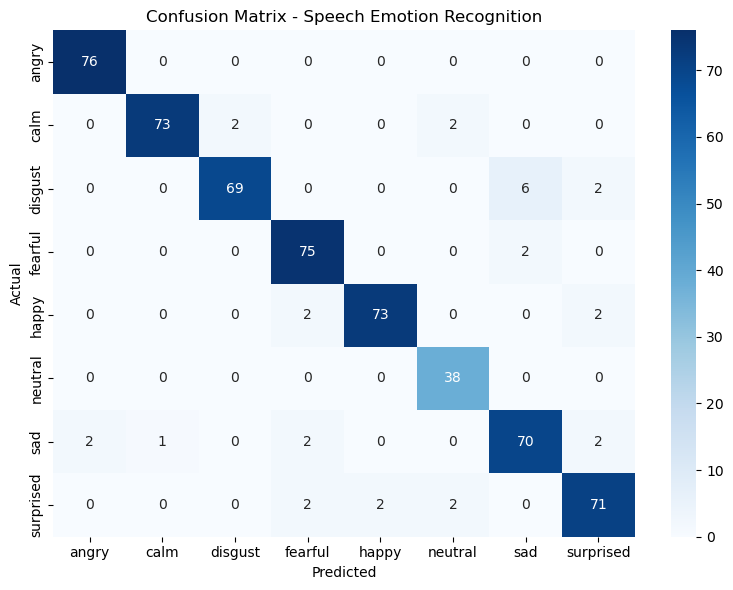

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Speech Emotion Recognition')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()

In [24]:
import pickle

os.makedirs('models', exist_ok=True)

model.save('models/emotion_model.h5')

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Model, scaler, and label encoder saved to models/')

Model, scaler, and label encoder saved to models/


In [26]:
TEST_FILE = '../../my_voice_test.wav' 

def predict_emotion(file_path, model, scaler, label_encoder):
    feat = extract_features(file_path).reshape(1, -1)
    feat_scaled = scaler.transform(feat)
    probs = model.predict(feat_scaled)[0]
    predicted_label = label_encoder.inverse_transform([np.argmax(probs)])[0]

    print('Predicted emotion:', predicted_label)
    print('\nConfidence scores:')
    for label, prob in sorted(zip(label_encoder.classes_, probs), key=lambda x: -x[1]):
        print(f'  {label:10s}: {prob:.3f}')
    return predicted_label

if os.path.exists(TEST_FILE):
    predict_emotion(TEST_FILE, model, scaler, le)
else:
    print(f'File not found: {TEST_FILE}. Record a short .wav clip and update TEST_FILE above.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted emotion: disgust

Confidence scores:
  disgust   : 1.000
  happy     : 0.000
  calm      : 0.000
  sad       : 0.000
  fearful   : 0.000
  angry     : 0.000
  surprised : 0.000
  neutral   : 0.000
